# 2025 Validation — True Holdout Test

## Why this notebook exists

All Day 4-6 model selection happened with 2024 as the test set. There's a real risk the 6-feature linear regression "won" simply because it overfits 2024-specific dynamics.

The 2025 F1 season completed in December 2025 — a full 24-race season the model has *never seen*. This is the proper test of generalisation.

## Setup

- **Train**: 2022 + 2023 + 2024 (all data prior to 2025)
- **Test**: 2025 (true holdout — never used for any decision)
- **Model**: 6-feature linear regression (the Day 6 final selection)
- **Baseline**: pole-sitter wins

## What we're testing

1. Does the 6-feature linear regression's RMSE advantage over pole baseline hold on 2025?
2. Does it still hit ~78% top-3 accuracy?
3. How does the pole baseline itself perform on 2025? (We already know 2025 has 66.7% pole-to-win conversion — pole baseline will be very strong.)

## What we expect — honest priors

2025 had **higher pole-to-win conversion than 2024** (66.7% vs 50%). This means:

- Pole baseline will be *harder* to beat on top-1 in 2025 than in 2024
- But our model's RMSE advantage should hold or improve, since 2025 is even more "predictable" via qualifying
- Top-3 accuracy should stay strong

If the model holds up directionally on 2025, we have a validated portfolio piece. If it doesn't, that's a publishable finding about distribution shift.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/ompatil9819gmail.com/F1-Race-Predictor


In [3]:
# Load full 4-season dataset
df = pd.read_csv(DATA_PROCESSED / "features_2022_2025.csv")

# Drop DNFs
df = df.dropna(subset=["Position"]).copy()

# Feature set: same 6 features as Day 6 final model
features = [
    "GridPosition", "QualifyingPosition", "QualifyingGapToPole",
    "DriverFormLast3", "TeamFormLast3", "IsStreetCircuit",
]

# Drop rows with missing critical features
df_clean = df.dropna(subset=features).copy()

# Train: 2022-2024, Test: 2025
train_df = df_clean[df_clean["Year"].isin([2022, 2023, 2024])].copy()
test_df = df_clean[df_clean["Year"] == 2025].copy()
test_df["race_id"] = test_df["Year"].astype(str) + "-R" + test_df["Round"].astype(str)

X_train = train_df[features]
y_train = train_df["Position"]
X_test = test_df[features]
y_test = test_df["Position"]
race_ids_test = test_df["race_id"]

print(f"Train: {len(X_train)} rows ({train_df['Round'].nunique()} unique rounds across {sorted(train_df['Year'].unique())})")
print(f"Test:  {len(X_test)} rows ({test_df['Round'].nunique()} unique rounds in 2025)")
print(f"Features: {len(features)}")

Train: 1296 rows (24 unique rounds across [np.int64(2022), np.int64(2023), np.int64(2024)])
Test:  468 rows (24 unique rounds in 2025)
Features: 6


In [4]:
def evaluate_predictions(y_true, y_pred, race_ids, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    eval_df = pd.DataFrame({
        "race_id": race_ids,
        "y_true": y_true.values if hasattr(y_true, "values") else y_true,
        "y_pred": y_pred,
    })

    eval_df["pred_rank"] = eval_df.groupby("race_id")["y_pred"].rank(method="min")
    eval_df["true_rank"] = eval_df.groupby("race_id")["y_true"].rank(method="min")

    actual_winners = eval_df[eval_df["true_rank"] == 1]
    predicted_winners = eval_df[eval_df["pred_rank"] == 1]
    races_with_winner_match = actual_winners.merge(
        predicted_winners, on="race_id", suffixes=("_actual", "_predicted")
    )
    top1_correct = (races_with_winner_match["y_true_actual"] == races_with_winner_match["y_true_predicted"]).sum()
    n_races = eval_df["race_id"].nunique()
    top1_accuracy = top1_correct / n_races

    top3_pred = eval_df[eval_df["pred_rank"] <= 3]
    top3_hits = 0
    for race_id in eval_df["race_id"].unique():
        actual_winner_pos = eval_df[(eval_df["race_id"] == race_id) & (eval_df["true_rank"] == 1)]["y_true"].iloc[0]
        race_top3_predicted = top3_pred[top3_pred["race_id"] == race_id]
        if actual_winner_pos in race_top3_predicted["y_true"].values:
            top3_hits += 1
    top3_accuracy = top3_hits / n_races

    print(f"\n=== {label} ===")
    print(f"  RMSE:           {rmse:.3f} positions")
    print(f"  MAE:            {mae:.3f} positions")
    print(f"  Top-1 accuracy: {top1_accuracy:.1%}  ({top1_correct}/{n_races} races)")
    print(f"  Top-3 accuracy: {top3_accuracy:.1%}  ({top3_hits}/{n_races} races)")

    return {"rmse": rmse, "mae": mae, "top1": top1_accuracy, "top3": top3_accuracy}

In [5]:
# Baseline: pole-sitter wins
results_pole_2025 = evaluate_predictions(
    y_test, test_df["QualifyingPosition"].values, race_ids_test,
    label="Baseline (pole) — 2025"
)

# Final model: 6-feature linear regression (re-trained on 2022-2024 this time)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_final = LinearRegression()
lr_final.fit(X_train_scaled, y_train)
y_pred_lr_2025 = lr_final.predict(X_test_scaled)

results_lr_2025 = evaluate_predictions(
    y_test, y_pred_lr_2025, race_ids_test,
    label="Linear Regression (6f) — 2025"
)


=== Baseline (pole) — 2025 ===
  RMSE:           4.686 positions
  MAE:            3.252 positions
  Top-1 accuracy: 66.7%  (16/24 races)
  Top-3 accuracy: 95.8%  (23/24 races)

=== Linear Regression (6f) — 2025 ===
  RMSE:           4.221 positions
  MAE:            3.247 positions
  Top-1 accuracy: 58.3%  (14/24 races)
  Top-3 accuracy: 100.0%  (24/24 races)


/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [6]:
# Day 6 results (from training on 2022-2023, testing on 2024)
results_pole_2024 = {"rmse": 4.036, "mae": 2.798, "top1": 0.522, "top3": 0.783}
results_lr_2024 = {"rmse": 3.736, "mae": 2.850, "top1": 0.435, "top3": 0.783}

comparison = pd.DataFrame({
    "Pole (2024 test)": results_pole_2024,
    "Linear Reg (2024 test)": results_lr_2024,
    "Pole (2025 test)": results_pole_2025,
    "Linear Reg (2025 test)": results_lr_2025,
}).T[["rmse", "mae", "top1", "top3"]]

print("\n=== Generalisation: 2024 test vs 2025 holdout ===")
print(comparison.round(3).to_string())

# Did the model generalise?
print("\n=== Generalisation deltas ===")
rmse_advantage_2024 = results_pole_2024["rmse"] - results_lr_2024["rmse"]
rmse_advantage_2025 = results_pole_2025["rmse"] - results_lr_2025["rmse"]
print(f"RMSE advantage over pole (2024 test):   {rmse_advantage_2024:+.3f}")
print(f"RMSE advantage over pole (2025 holdout): {rmse_advantage_2025:+.3f}")
print(f"Top-3 accuracy preserved? 2024: {results_lr_2024['top3']:.1%}  2025: {results_lr_2025['top3']:.1%}")


=== Generalisation: 2024 test vs 2025 holdout ===
                         rmse    mae   top1   top3
Pole (2024 test)        4.036  2.798  0.522  0.783
Linear Reg (2024 test)  3.736  2.850  0.435  0.783
Pole (2025 test)        4.686  3.252  0.667  0.958
Linear Reg (2025 test)  4.221  3.247  0.583  1.000

=== Generalisation deltas ===
RMSE advantage over pole (2024 test):   +0.300
RMSE advantage over pole (2025 holdout): +0.465
Top-3 accuracy preserved? 2024: 78.3%  2025: 100.0%


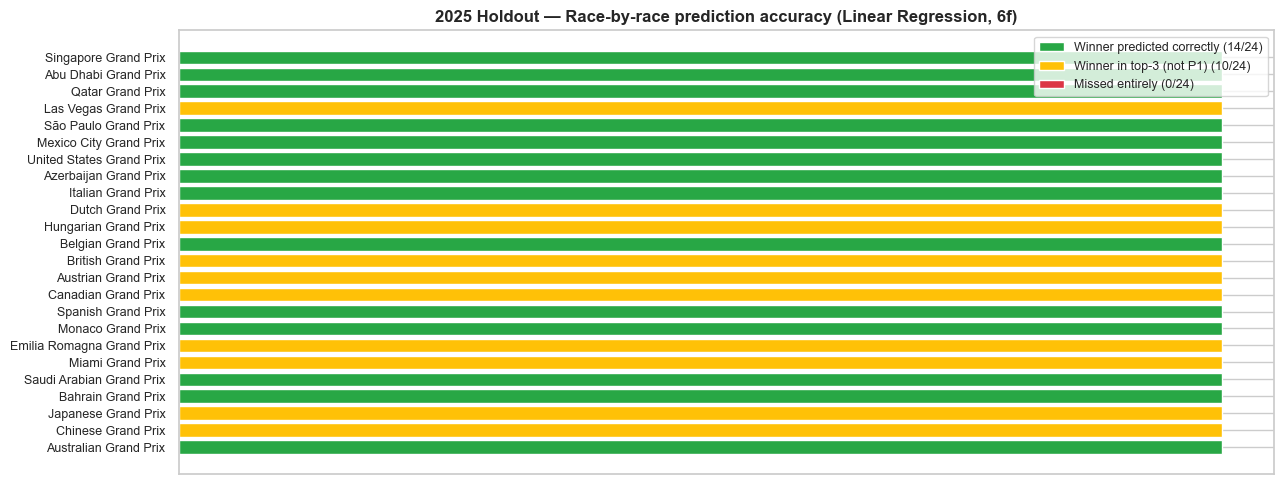


Winner correctly predicted: 14/24
Winner in top-3 prediction: 24/24
Missed entirely:            0/24


In [8]:
def per_race_accuracy(y_true, y_pred, race_ids, eventnames):
    eval_df = pd.DataFrame({
        "race_id": race_ids.values,
        "eventname": eventnames.values,
        "y_true": y_true.values,
        "y_pred": y_pred,
    })
    eval_df["pred_rank"] = eval_df.groupby("race_id")["y_pred"].rank(method="min")
    eval_df["true_rank"] = eval_df.groupby("race_id")["y_true"].rank(method="min")

    races = []
    for race_id in eval_df["race_id"].unique():
        sub = eval_df[eval_df["race_id"] == race_id]
        actual_winner = sub[sub["true_rank"] == 1]["y_true"].iloc[0]
        predicted_winner_position = sub[sub["pred_rank"] == 1]["y_true"].iloc[0]
        actual_winner_in_top3 = sub[sub["pred_rank"] <= 3]["y_true"].min() == actual_winner
        races.append({
            "race_id": race_id,
            "event": sub["eventname"].iloc[0],
            "winner_correct": predicted_winner_position == actual_winner,
            "top3_hit": actual_winner_in_top3,
        })
    return pd.DataFrame(races)

race_accuracy_2025 = per_race_accuracy(
    y_test, y_pred_lr_2025, race_ids_test, test_df["EventName"]
)

fig, ax = plt.subplots(figsize=(13, 5))
y_pos = range(len(race_accuracy_2025))
colors = ["#28a745" if w else ("#ffc107" if t else "#dc3545")
          for w, t in zip(race_accuracy_2025["winner_correct"], race_accuracy_2025["top3_hit"])]
ax.barh(y_pos, [1] * len(race_accuracy_2025), color=colors, edgecolor="white", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(race_accuracy_2025["event"], fontsize=9)
ax.set_xticks([])
ax.set_title("2025 Holdout — Race-by-race prediction accuracy (Linear Regression, 6f)",
             fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#28a745", label=f"Winner predicted correctly ({race_accuracy_2025['winner_correct'].sum()}/24)"),
    Patch(facecolor="#ffc107", label=f"Winner in top-3 (not P1) ({(race_accuracy_2025['top3_hit'] & ~race_accuracy_2025['winner_correct']).sum()}/24)"),
    Patch(facecolor="#dc3545", label=f"Missed entirely ({(~race_accuracy_2025['top3_hit']).sum()}/24)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_2025_race_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nWinner correctly predicted: {race_accuracy_2025['winner_correct'].sum()}/24")
print(f"Winner in top-3 prediction: {race_accuracy_2025['top3_hit'].sum()}/24")
print(f"Missed entirely:            {(~race_accuracy_2025['top3_hit']).sum()}/24")

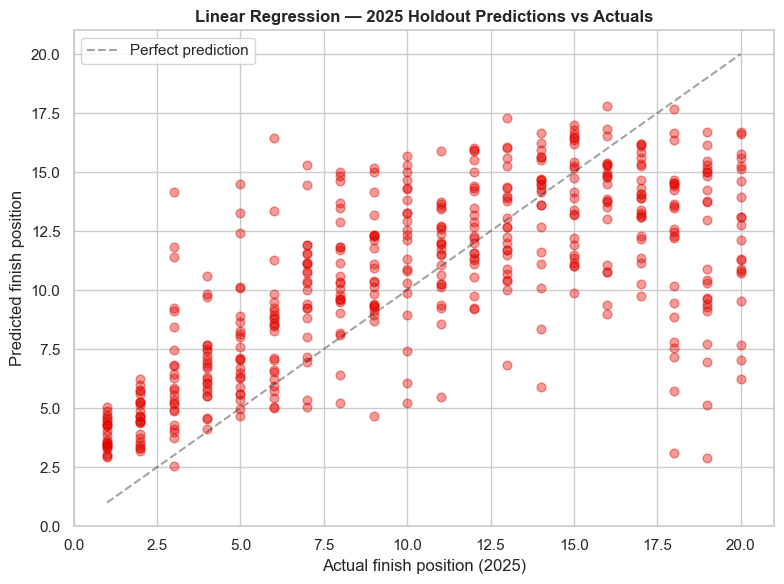

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_lr_2025, alpha=0.4, s=40, color="#E10600")
ax.plot([1, 20], [1, 20], "k--", alpha=0.4, label="Perfect prediction")
ax.set_xlabel("Actual finish position (2025)")
ax.set_ylabel("Predicted finish position")
ax.set_title("Linear Regression — 2025 Holdout Predictions vs Actuals", fontsize=12, fontweight="bold")
ax.set_xlim(0, 21); ax.set_ylim(0, 21)
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_2025_predictions.png", dpi=120, bbox_inches="tight")
plt.show()